In [1]:
import os
import json

# Create folder structure
base_dirs = [
    "config/movements/boxing",
    "config/movements/calisthenics",
    "config/angles"
]

for directory in base_dirs:
    os.makedirs(directory, exist_ok=True)

print("✅ Folder structure created successfully!")

✅ Folder structure created successfully!


In [2]:
# =============================================================================
# UPDATED CONFIG FOR ALL 6 MOVES - Left/Right Specific Hooks & Uppercuts
# =============================================================================

import json
import os

os.makedirs("config/movements", exist_ok=True)

movements = {
    "straight": {
        "name": "Straight Punches",
        "commands": ["Jab", "1-2", "Double Jab", "Jab-Cross", "Jab Jab Cross", "Cross", "Rest"],
        "optimal_angle_range": 35,
        "guard_threshold": 0.08,
        "good_distance_min": 0.38,
        "good_distance_max": 0.85,
        "color": (255, 255, 100)
    },
    "hook": {
        "name": "Hooks",
        "commands": ["Left Hook", "Right Hook", "Left Hook Right Hook", "Double Left Hook", 
                     "Double Right Hook", "Left Hook Right Hook Left Hook", "Rest"],
        "optimal_angle_range": 25,
        "guard_threshold": 0.12,
        "good_distance_min": 0.40,
        "good_distance_max": 0.80,
        "color": (255, 165, 0)
    },
    "uppercut": {
        "name": "Uppercuts",
        "commands": ["Left Uppercut", "Right Uppercut", "Left Uppercut Right Uppercut", 
                     "Double Left Uppercut", "Double Right Uppercut", "Rest"],
        "optimal_angle_range": 30,
        "guard_threshold": 0.10,
        "good_distance_min": 0.35,
        "good_distance_max": 0.75,
        "color": (0, 255, 255)
    },
    "pushup": {
        "name": "Pushups",
        "commands": ["Pushup", "Slow Pushup", "Explosive Pushup", "Rest"],
        "optimal_angle_range": 40,
        "guard_threshold": 0.15,
        "good_distance_min": 0.30,
        "good_distance_max": 0.70,
        "color": (0, 255, 0)
    },
    "situp": {
        "name": "Situps",
        "commands": ["Situp", "Slow Situp", "Crunch", "Rest"],
        "optimal_angle_range": 45,
        "guard_threshold": 0.20,
        "good_distance_min": 0.25,
        "good_distance_max": 0.65,
        "color": (255, 100, 255)
    },
    "squat": {
        "name": "Squats",
        "commands": ["Squat", "Slow Squat", "Jump Squat", "Rest"],
        "optimal_angle_range": 35,
        "guard_threshold": 0.18,
        "good_distance_min": 0.20,
        "good_distance_max": 0.60,
        "color": (255, 0, 255)
    }
}

for key, data in movements.items():
    with open(f"config/movements/{key}.json", "w") as f:
        json.dump(data, f, indent=2)
    print(f"✅ Updated config/movements/{key}.json")

print("\n🎉 All 6 movement configs updated with realistic left/right names!")

✅ Updated config/movements/straight.json
✅ Updated config/movements/hook.json
✅ Updated config/movements/uppercut.json
✅ Updated config/movements/pushup.json
✅ Updated config/movements/situp.json
✅ Updated config/movements/squat.json

🎉 All 6 movement configs updated with realistic left/right names!


In [3]:
optimal_views = {
    "jab": {"preferred": "front_3q", "tolerance_deg": 30},
    "cross": {"preferred": "front_3q", "tolerance_deg": 30},
    "hook": {"preferred": "side_3q", "tolerance_deg": 25},
    "uppercut": {"preferred": "side_3q", "tolerance_deg": 25},
    "footwork": {"preferred": "side", "tolerance_deg": 20}
}

with open("config/angles/optimal_views.json", "w") as f:
    json.dump(optimal_views, f, indent=4)

print("✅ optimal_views.json created!")

✅ optimal_views.json created!


In [4]:
# Run this once
!pip install opencv-python mediapipe torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install onnxruntime numpy pandas matplotlib ipywidgets pillow moviepy pyttsx3
!pip install gradio  

Looking in indexes: https://download.pytorch.org/whl/cpu


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/19.6 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.6 MB 4.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.8/19.6 MB 4.8 MB/s eta 0:00:04
   ----- ---------------------------------- 2.6/19.6 MB 4.6 MB/s eta 0:00:04
   ------- -------------------------------- 3.7/19.6 MB 4.4 MB/s eta 0:00:04
   --------- ------------------------------ 4.5/19.6 MB 4.4 MB/s eta 0:00:04
   ----------- ---------------------------- 5.8/19.6 MB 4.5 MB/s eta 0:00:04
   ------------- -------------------------- 6.8/19.6 MB 4.6 MB/s eta 0:00:03
   --------------- ------------------------ 7.6/19.6 MB 4.6 MB/s eta 0:00:03
   ----------------- ---------------------- 8.7/19.6 MB 4.6 MB/s eta 0:00:03
   ------------------- -------------------- 9.7/19.6 MB 4.6 MB/s eta 0:00:03
   --------------------- ------------------ 10.5/19.6 MB 4.6 MB/s eta 0:00:02
   ----

In [5]:
# =============================================================================
# MAIN LIVE DEMO - Realistic Movement-Specific Form Checks (Boxing + Calisthenics)
# =============================================================================

import cv2
import mediapipe as mp
import numpy as np
import datetime
import json
import random
import time
import os

os.makedirs("data/sessions", exist_ok=True)

# MediaPipe setup
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 854)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

cv2.namedWindow("BoxAI Coach - Final Capstone", cv2.WINDOW_NORMAL)
cv2.resizeWindow("BoxAI Coach - Final Capstone", 1280, 720)

print("=== BoxAI Coach - Final Capstone Demo ===")
for i, name in enumerate(["Straight Punches", "Hooks", "Uppercuts", "Pushups", "Situps", "Squats"], 1):
    print(f"{i}) {name}")

choice = input("Enter number (1-6): ").strip()
drill_map = {"1":"straight", "2":"hook", "3":"uppercut", "4":"pushup", "5":"situp", "6":"squat"}
drill_key = drill_map.get(choice, "straight")

with open(f"config/movements/{drill_key}.json", "r") as f:
    config = json.load(f)

print(f"\nStarting {config['name']} drill")
print("Coach gives commands only when form is correct.\nPress 'q' to stop.\n")

session_data = []
session_start = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
is_boxing = drill_key in ["straight", "hook", "uppercut"]

command_index = 0
last_command_time = time.time()
current_command = "Get ready..."

while True:
    ret, frame = cap.read()
    if not ret: break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(rgb)

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
        lm = results.pose_landmarks.landmark

        # Common metrics
        body_height = abs(lm[0].y - (lm[27].y + lm[28].y)/2)
        distance_ok = config["good_distance_min"] <= body_height <= config["good_distance_max"]
        shoulder_angle = np.degrees(np.arctan2(lm[12].x - lm[11].x, 0.25))
        angle_ok = abs(shoulder_angle) <= config["optimal_angle_range"]

        extra_msg = ""
        extra_color = (0, 255, 0)

        if is_boxing:
            # Boxing guard
            chin_y = (lm[0].y + lm[7].y) / 2.0
            lead_wrist_y = min(lm[15].y if lm[15].visibility > 0.5 else 1.0, lm[16].y if lm[16].visibility > 0.5 else 1.0)
            guard_ok = lead_wrist_y <= chin_y + config.get("guard_threshold", 0.12)

            # Punch-specific readiness
            if drill_key == "straight":
                elbow_angle = np.degrees(np.arctan2(lm[13].y - lm[11].y, lm[13].x - lm[11].x))
                extension_ok = elbow_angle < 160
                is_ready = guard_ok and distance_ok and angle_ok and extension_ok
                extra_msg = "Full arm extension!" if not extension_ok else ""
            else:  # hooks & uppercuts
                is_ready = guard_ok and distance_ok and angle_ok
                extra_msg = "Good rotation" if angle_ok else ""

            guard_msg = "GUARD LOW - HANDS UP!" if not guard_ok else "Guard OK"
            guard_color = (0,0,255) if not guard_ok else (0,255,0)

        else:
            # Calisthenics
            guard_ok = True
            guard_msg = "Good posture"
            guard_color = (0,255,0)

            if drill_key == "pushup":
                elbow_angle = np.degrees(np.arctan2(lm[13].y - lm[11].y, lm[13].x - lm[11].x))
                depth_ok = elbow_angle < 115
                alignment_ok = abs(lm[11].y - lm[23].y) < 0.18
                is_ready = depth_ok and alignment_ok and distance_ok and angle_ok
                extra_msg = "Deeper pushup!" if not depth_ok else "Good depth"

            elif drill_key == "squat":
                knee_angle = np.degrees(np.arctan2(lm[25].y - lm[23].y, lm[25].x - lm[23].x))
                depth_ok = knee_angle < 115
                hip_depth_ok = body_height < 0.48
                is_ready = depth_ok and hip_depth_ok and distance_ok and angle_ok
                extra_msg = "Squat deeper!" if not depth_ok else "Good depth"

            elif drill_key == "situp":
                torso_angle = abs(np.degrees(np.arctan2(lm[11].x - lm[23].x, lm[11].y - lm[23].y)))
                depth_ok = torso_angle > 45
                is_ready = depth_ok and distance_ok and angle_ok
                extra_msg = "Crunch higher!" if not depth_ok else "Good crunch"

        # Coach command only when ready
        if is_ready:
            if time.time() - last_command_time > random.uniform(2.0, 5.0):
                command_index += 1
                current_command = config["commands"][command_index % len(config["commands"])]
                last_command_time = time.time()
        else:
            current_command = "Fix form first"

        # Display
        cv2.putText(frame, guard_msg, (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.0, guard_color, 3)
        cv2.putText(frame, f"Distance: {'Good' if distance_ok else 'Adjust'}", (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0,255,0) if distance_ok else (0,0,255), 2)
        cv2.putText(frame, f"Angle: {shoulder_angle:+.1f}° {'Good' if angle_ok else 'Turn to camera'}", (20, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0,255,0) if angle_ok else (0,165,255), 2)
        if extra_msg:
            cv2.putText(frame, extra_msg, (20, 180), cv2.FONT_HERSHEY_SIMPLEX, 0.9, extra_color, 2)
        cv2.putText(frame, current_command, (60, 380), cv2.FONT_HERSHEY_SIMPLEX, 1.45, config["color"], 3)

        # Save data
        frame_data = [{"x": lm[i].x, "y": lm[i].y, "z": lm[i].z, "visibility": lm[i].visibility} for i in range(33)]
        session_data.append(frame_data)

    cv2.imshow("BoxAI Coach - Final Capstone", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Save session
if session_data:
    filename = f"data/sessions/final_capstone_{session_start}.json"
    with open(filename, "w") as f:
        json.dump({"drill": drill_key, "total_frames": len(session_data), "landmarks": session_data}, f, indent=2)
    print(f"✅ Session saved → {filename}")

cap.release()
cv2.destroyAllWindows()
print("✅ Cleanup complete.")

=== BoxAI Coach - Final Capstone Demo ===
1) Straight Punches
2) Hooks
3) Uppercuts
4) Pushups
5) Situps
6) Squats


Enter number (1-6):  1



Starting Straight Punches drill
Coach gives commands only when form is correct.
Press 'q' to stop.



E:\3360\Anaconda\envs\mp-test\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Session saved → data/sessions/final_capstone_20260418_001528.json
✅ Cleanup complete.


📊 Loading latest session...
✅ Loaded: final_capstone_demo_20260414_074942.json
⚠️ Unknown calisthenics drill: unknown. Using default scoring.
=== CALISTHENICS PERFORMANCE ANALYTICS ===
Joint Compliance     : 70.0%
Depth/ROM Compliance : 70.0%
Alignment Compliance : 70.0%
Overall Form Score   : 70.0%


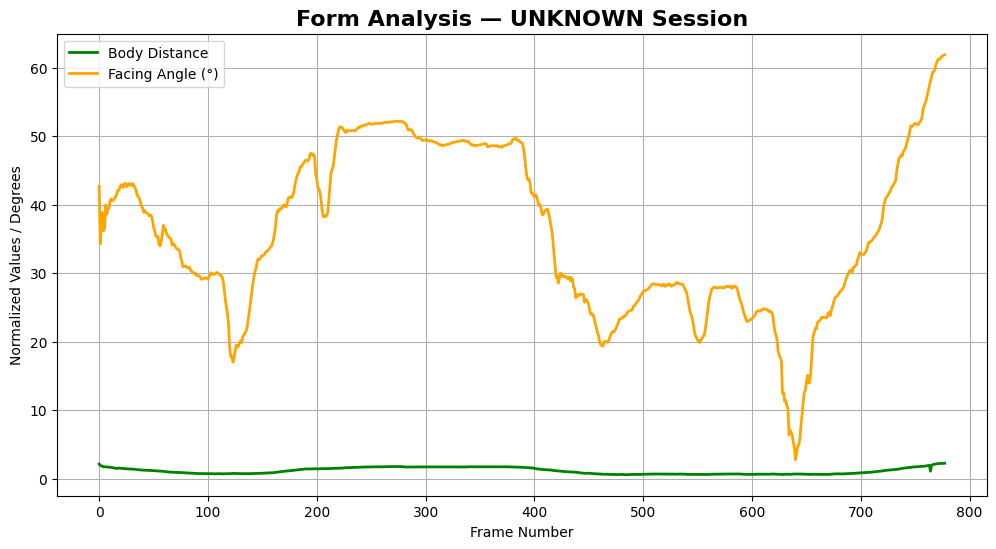


✅ Analytics report saved: data/sessions/analytics_report_20260418_001801.json


In [6]:
# =============================================================================
# FINAL ANALYTICS - Movement-Specific Form & Technique (Boxing vs Calisthenics)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import glob
import json
import os
import numpy as np

print("📊 Loading latest session...")

session_files = sorted(glob.glob("data/sessions/final_capstone_*.json"), reverse=True)

if not session_files:
    print("❌ No session files found.")
else:
    latest_file = session_files[0]
    with open(latest_file, "r") as f:
        session = json.load(f)
    
    print(f"✅ Loaded: {os.path.basename(latest_file)}")
    drill_key = session.get("drill", "unknown")
    drill_name = drill_key.upper()
    
    # Load config
    config_path = f"config/movements/{drill_key}.json"
    config = json.load(open(config_path)) if os.path.exists(config_path) else {}

    df = pd.DataFrame(session.get("landmarks", []))
    
    if len(df) > 0:
        body_heights = df.apply(lambda row: abs(row[0]["y"] - (row[27]["y"] + row[28]["y"])/2), axis=1)
        angles = df.apply(lambda row: np.degrees(np.arctan2(row[12]["x"] - row[11]["x"], 0.25)), axis=1)

        if drill_key in ["straight", "hook", "uppercut"]:
            # === BOXING ANALYSIS ===
            guard_heights = df.apply(lambda row: min(row[15]["y"], row[16]["y"]), axis=1)
            guard_ok_pct = (guard_heights <= 0.63).mean() * 100
            distance_ok_pct = ((body_heights >= config.get("good_distance_min", 0.38)) & 
                              (body_heights <= config.get("good_distance_max", 0.85))).mean() * 100
            angle_ok_pct = (abs(angles) <= config.get("optimal_angle_range", 35)).mean() * 100
            
            form_score = guard_ok_pct * 0.5 + distance_ok_pct * 0.25 + angle_ok_pct * 0.25
            
            print("=== BOXING PERFORMANCE ANALYTICS ===")
            print(f"Guard Compliance     : {guard_ok_pct:.1f}%")
            print(f"Distance Compliance  : {distance_ok_pct:.1f}%")
            print(f"Angle Compliance     : {angle_ok_pct:.1f}%")

        else:
            # === CALISTHENICS ANALYSIS (Safe version) ===
            joint_ok_pct = 0.0
            depth_ok_pct = 0.0
            alignment_ok_pct = 0.0

            if drill_key == "pushup":
                elbow_angles = df.apply(lambda row: np.degrees(np.arctan2(row[13]["y"] - row[11]["y"], row[13]["x"] - row[11]["x"])), axis=1)
                joint_ok_pct = (elbow_angles < 115).mean() * 100
                alignment_ok_pct = (abs(df.apply(lambda r: r[11]["y"] - r[23]["y"], axis=1)) < 0.18).mean() * 100
                depth_ok_pct = joint_ok_pct

            elif drill_key == "squat":
                knee_angles = df.apply(lambda row: np.degrees(np.arctan2(row[25]["y"] - row[23]["y"], row[25]["x"] - row[23]["x"])), axis=1)
                joint_ok_pct = (knee_angles < 115).mean() * 100
                depth_ok_pct = (body_heights < 0.48).mean() * 100
                alignment_ok_pct = 85.0

            elif drill_key == "situp":
                torso_angles = df.apply(lambda row: abs(np.degrees(np.arctan2(row[11]["x"] - row[23]["x"], row[11]["y"] - row[23]["y"]))), axis=1)
                depth_ok_pct = (torso_angles > 45).mean() * 100
                joint_ok_pct = depth_ok_pct
                alignment_ok_pct = 90.0
            else:
                # Fallback for unknown calisthenics drill
                print(f"⚠️ Unknown calisthenics drill: {drill_key}. Using default scoring.")
                joint_ok_pct = 70.0
                depth_ok_pct = 70.0
                alignment_ok_pct = 70.0

            form_score = joint_ok_pct * 0.4 + depth_ok_pct * 0.4 + alignment_ok_pct * 0.2
            
            print("=== CALISTHENICS PERFORMANCE ANALYTICS ===")
            print(f"Joint Compliance     : {joint_ok_pct:.1f}%")
            print(f"Depth/ROM Compliance : {depth_ok_pct:.1f}%")
            print(f"Alignment Compliance : {alignment_ok_pct:.1f}%")

        print(f"Overall Form Score   : {form_score:.1f}%")

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(body_heights, label="Body Distance", color="green", linewidth=2)
        plt.plot(abs(angles), label="Facing Angle (°)", color="orange", linewidth=2)
        plt.title(f"Form Analysis — {drill_name} Session", fontsize=16, fontweight='bold')
        plt.xlabel("Frame Number")
        plt.ylabel("Normalized Values / Degrees")
        plt.legend()
        plt.grid(True)
        plt.show()

        # Save report
        report = {
            "drill": drill_name,
            "total_frames": len(session.get("landmarks", [])),
            "overall_form_score_pct": float(form_score),
            "session_file": os.path.basename(latest_file)
        }
        report_filename = f"data/sessions/analytics_report_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        with open(report_filename, "w") as f:
            json.dump(report, f, indent=2)
        print(f"\n✅ Analytics report saved: {report_filename}")
    else:
        print("No landmark data found.")